### Stage 1: Success Probability Components

In this notebook we study the components of the success probability function with 100 and 10 workers. Do we see sufficient differentitaion? Is there evidence that we need to modify any part of the function? For this analysis we use the results of the Greedy method.

We also compare methods - Greedy versus GRASP, random and exhaustive search. (This analysis should probably be moved to another notebook and developed there.)

In [1]:
import pandas as pd
import pickle
import numpy as np
import superscript_abm

import matplotlib.pyplot as plt
%matplotlib inline

#### First we look at Greedy results for 100 and 10 workers (filtered using 'first_n').

In [3]:
def load_results(path):
    with open(path, 'rb') as infile:
        results = pickle.load(infile)
        
    return results

In [4]:
results_10_workers = load_results('../stage_1_results/single_algorithm/stage_1_100_projects_10_workers_nonlinear/dataset_1_greedy_run_0/results.pickle')

In [5]:
results_100_workers = load_results('../stage_1_results/single_algorithm/stage_1_100_projects_100_workers_nonlinear/dataset_1_greedy_run_0/results.pickle')

In [6]:
results_100_workers.keys()

dict_keys(['runtime', 'probability', 'team_size', 'workers', 'state_file', 'timeout', 'ovr', 'skill_balance', 'creativity_match', 'creativity_level', 'risk', 'individual_chemistry', 'team_chemistry', 'probability_ovr', 'probability_skill_balance', 'probability_creativity_match', 'probability_individual_chemistry', 'probability_team_chemistry', 'probability_risk'])

In [7]:
not_to_plot = ['workers', 'state_file', 'timeout']

runtime
probability
team_size
ovr
skill_balance
creativity_match
creativity_level
risk
individual_chemistry
team_chemistry
probability_ovr
probability_skill_balance
probability_creativity_match
probability_individual_chemistry
probability_team_chemistry
probability_risk


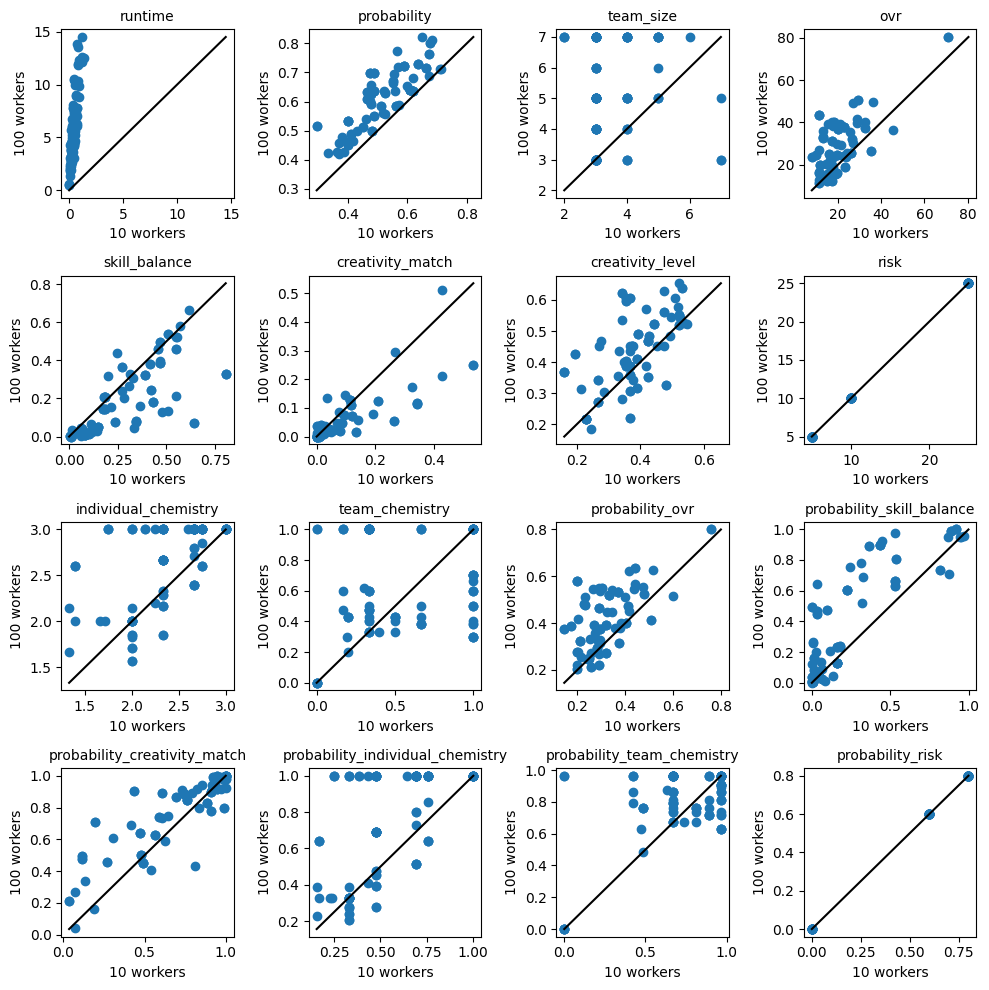

In [8]:
plot_id = 1
plt.figure(figsize=(10,10))
for key in results_100_workers.keys():
    if key not in not_to_plot:
        plt.subplot(4,4,plot_id)
        print(key)
        
        X = results_10_workers[key]
        Y = results_100_workers[key]
        plt.scatter(X, Y)
        
        _X = [xi for xi in X if xi is not None]
        _Y = [xi for xi in Y if xi is not None]
        x_min = min(_X)
        x_max = max(_X)
        y_min = min(_Y)
        y_max = max(_Y)
        
        mmin = min(x_min, y_min)
        mmax = max(x_max, y_max)
        
        plt.plot([mmin, mmax], [mmin, mmax], c='k')
        plt.xlabel('10 workers')
        plt.ylabel('100 workers')
        plt.title(key, fontsize=10);
        plot_id += 1

plt.tight_layout()

probability_ovr
probability_skill_balance
probability_creativity_match
probability_individual_chemistry
probability_team_chemistry
probability_risk


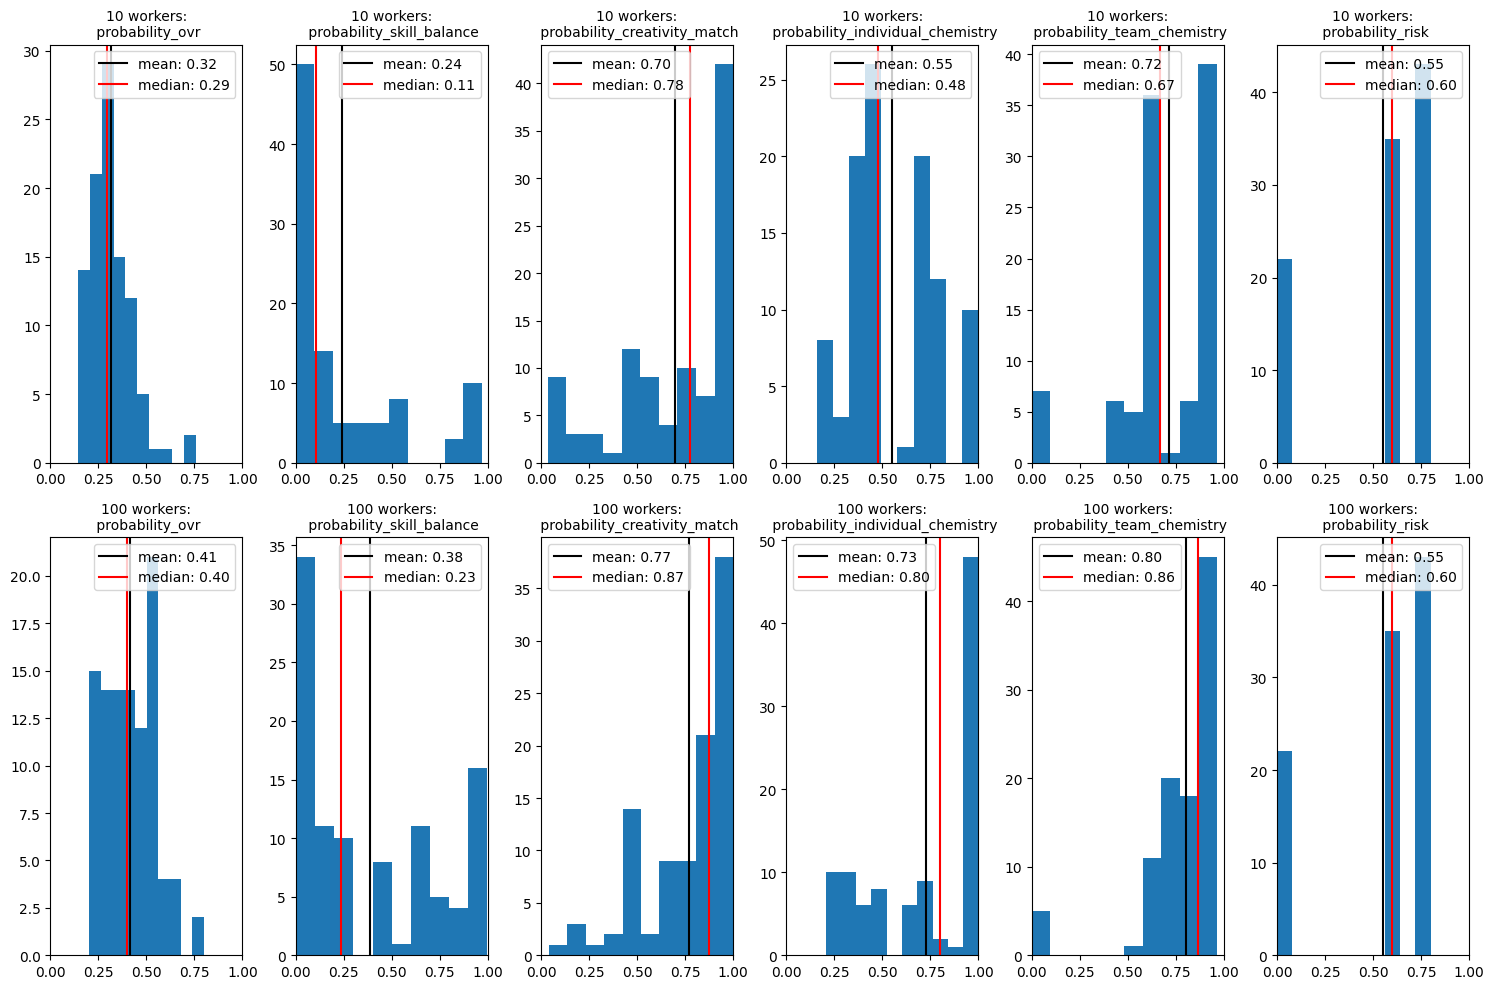

In [10]:
components = []
fs = 10

plot_id = 1
plt.figure(figsize=(15,10))
for key in results_100_workers.keys():
    if 'probability_' in key:
        
        components.append(key[12:])
        print(key)
        plt.subplot(2,6,plot_id)
        X = results_10_workers[key]
        plt.axvline(np.mean(X), c='k', label='mean: %.2f' % np.mean(X))
        plt.axvline(np.median(X), c='r', label='median: %.2f' % np.median(X))
        plt.hist(X)
        plt.xlim([0,1])
        plt.legend()
        plt.title('10 workers:\n %s' % key, fontsize=fs)
        
        plt.subplot(2,6,plot_id+6)
        Y = results_100_workers[key]
        plt.axvline(np.mean(Y), c='k', label='mean: %.2f' % np.mean(Y))
        plt.axvline(np.median(Y), c='r', label='median: %.2f' % np.median(Y))
        plt.xlim([0,1])
        plt.hist(Y)
        plt.legend()
        plt.title('100 workers:\n %s' % key, fontsize=fs)

        plot_id += 1

plt.tight_layout()

## In the linear scenario, there is a problem with creativity_match...needs investigating.
## Suggest changing the gradient of this cpt function. (Any others?)

In [11]:
components

['ovr',
 'skill_balance',
 'creativity_match',
 'individual_chemistry',
 'team_chemistry',
 'risk']

In [12]:
bad_cpts =[
 'ovr',
 'skill_balance',
 'creativity_match',
 'creativity_level'
]

ovr
skill_balance
creativity_match
creativity_level


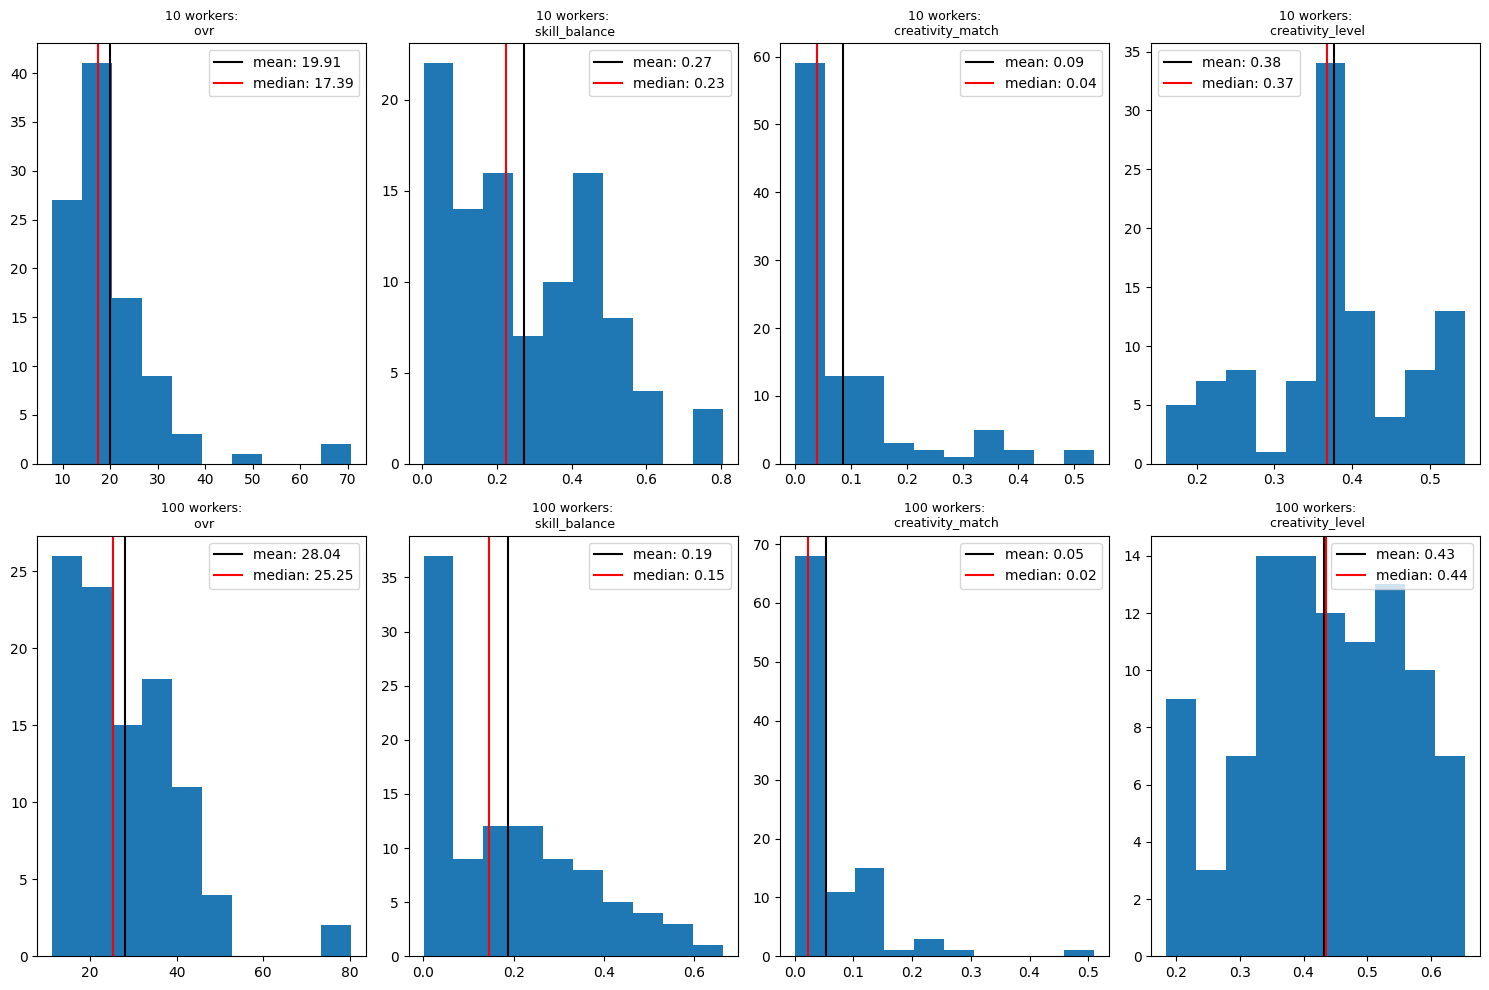

In [13]:
fs = 9
plot_id = 1
plt.figure(figsize=(15,10))
for cpt in bad_cpts:
        
        print(cpt)
        plt.subplot(2,4,plot_id)
        X = results_10_workers[cpt]
        plt.axvline(np.mean(X), c='k', label='mean: %.2f' % np.mean(X))
        plt.axvline(np.median(X), c='r', label='median: %.2f' % np.median(X))
        plt.hist(X)
#         plt.xlim([0,1])
        plt.legend()
        plt.title('10 workers:\n %s' % cpt, fontsize=fs)
        
        plt.subplot(2,4,plot_id+4)
        Y = results_100_workers[cpt]
        plt.axvline(np.mean(Y), c='k', label='mean: %.2f' % np.mean(Y))
        plt.axvline(np.median(Y), c='r', label='median: %.2f' % np.median(Y))
#         plt.xlim([0,1])
        plt.hist(Y)
        plt.legend()
        plt.title('100 workers:\n %s' % cpt, fontsize=fs)
#         plt.scatter(X, Y)
        
#         x_min = min(X)
#         x_max = max(X)
#         y_min = min(Y)
#         y_max = max(Y)
        
#         mmin = min(x_min, y_min)
#         mmax = max(x_max, y_max)
        
#         plt.plot([mmin, mmax], [mmin, mmax], c='k')
#         plt.xlabel('10 workers')
#         plt.ylabel('100 workers')
#         plt.title(key, fontsize=10);
        plot_id += 1

plt.tight_layout()

ovr
skill_balance
creativity_match
creativity_level


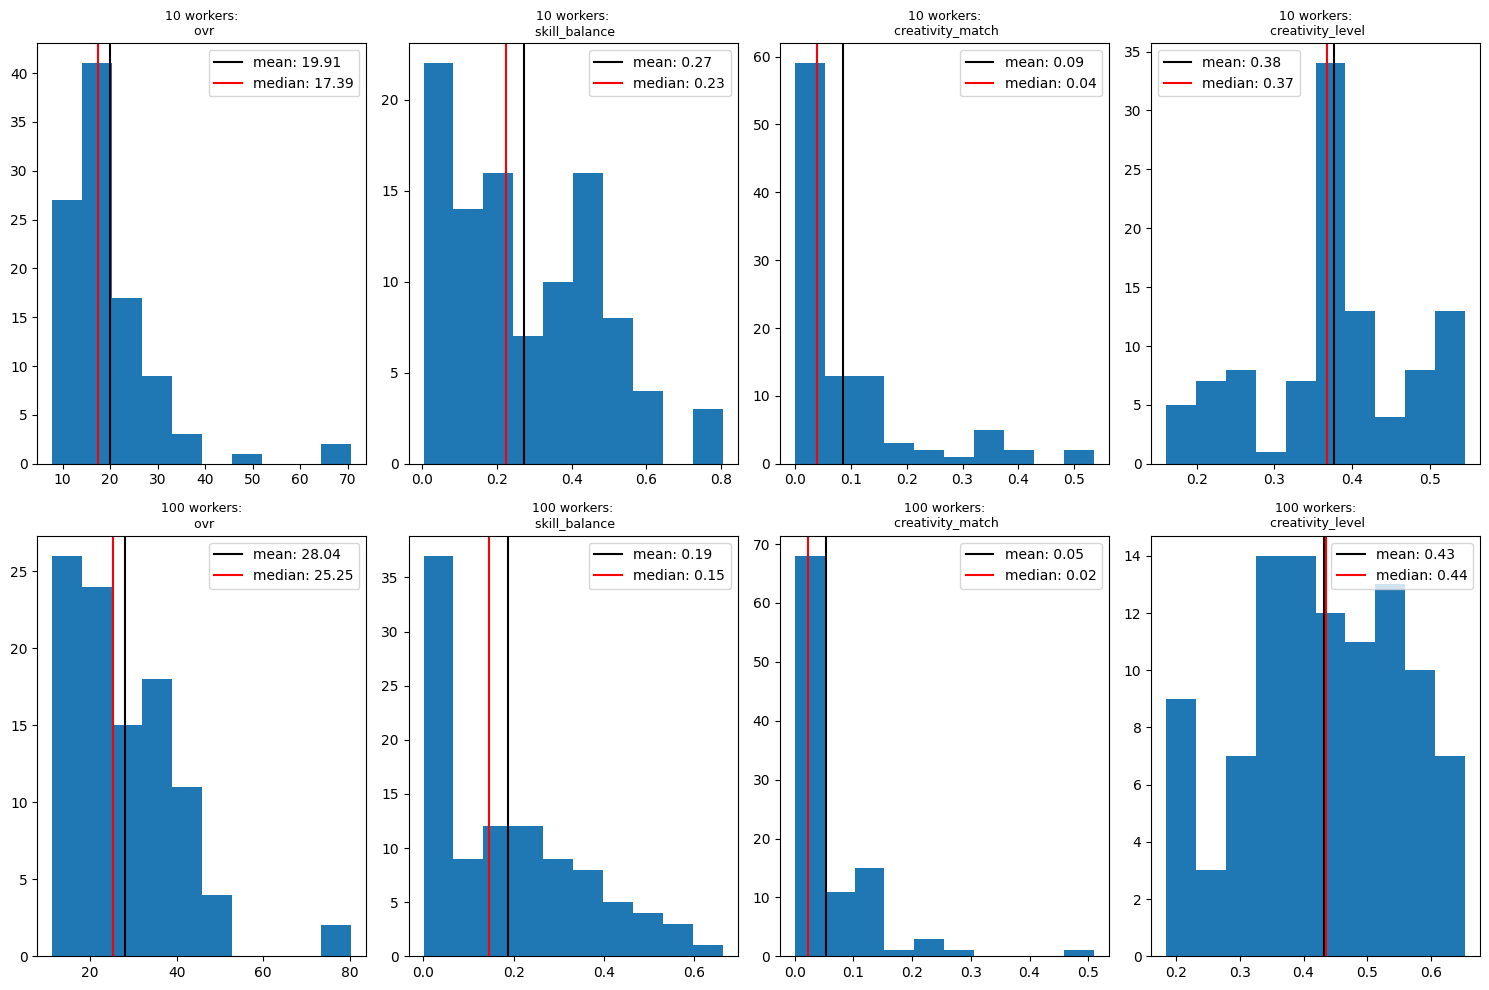

In [14]:
fs = 9
plot_id = 1
plt.figure(figsize=(15,10))
for cpt in bad_cpts:
        
        print(cpt)
        plt.subplot(2,4,plot_id)
        X = results_10_workers[cpt]
        plt.axvline(np.mean(X), c='k', label='mean: %.2f' % np.mean(X))
        plt.axvline(np.median(X), c='r', label='median: %.2f' % np.median(X))
        plt.hist(X)
#         plt.xlim([0,1])
        plt.legend()
        plt.title('10 workers:\n %s' % cpt, fontsize=fs)
        
        plt.subplot(2,4,plot_id+4)
        Y = results_100_workers[cpt]
        plt.axvline(np.mean(Y), c='k', label='mean: %.2f' % np.mean(Y))
        plt.axvline(np.median(Y), c='r', label='median: %.2f' % np.median(Y))
#         plt.xlim([0,1])
        plt.hist(Y)
        plt.legend()
        plt.title('100 workers:\n %s' % cpt, fontsize=fs)
#         plt.scatter(X, Y)
        
#         x_min = min(X)
#         x_max = max(X)
#         y_min = min(Y)
#         y_max = max(Y)
        
#         mmin = min(x_min, y_min)
#         mmax = max(x_max, y_max)
        
#         plt.plot([mmin, mmax], [mmin, mmax], c='k')
#         plt.xlabel('10 workers')
#         plt.ylabel('100 workers')
#         plt.title(key, fontsize=10);
        plot_id += 1

plt.tight_layout()

ovr
skill_balance
creativity_match
individual_chemistry
team_chemistry
risk


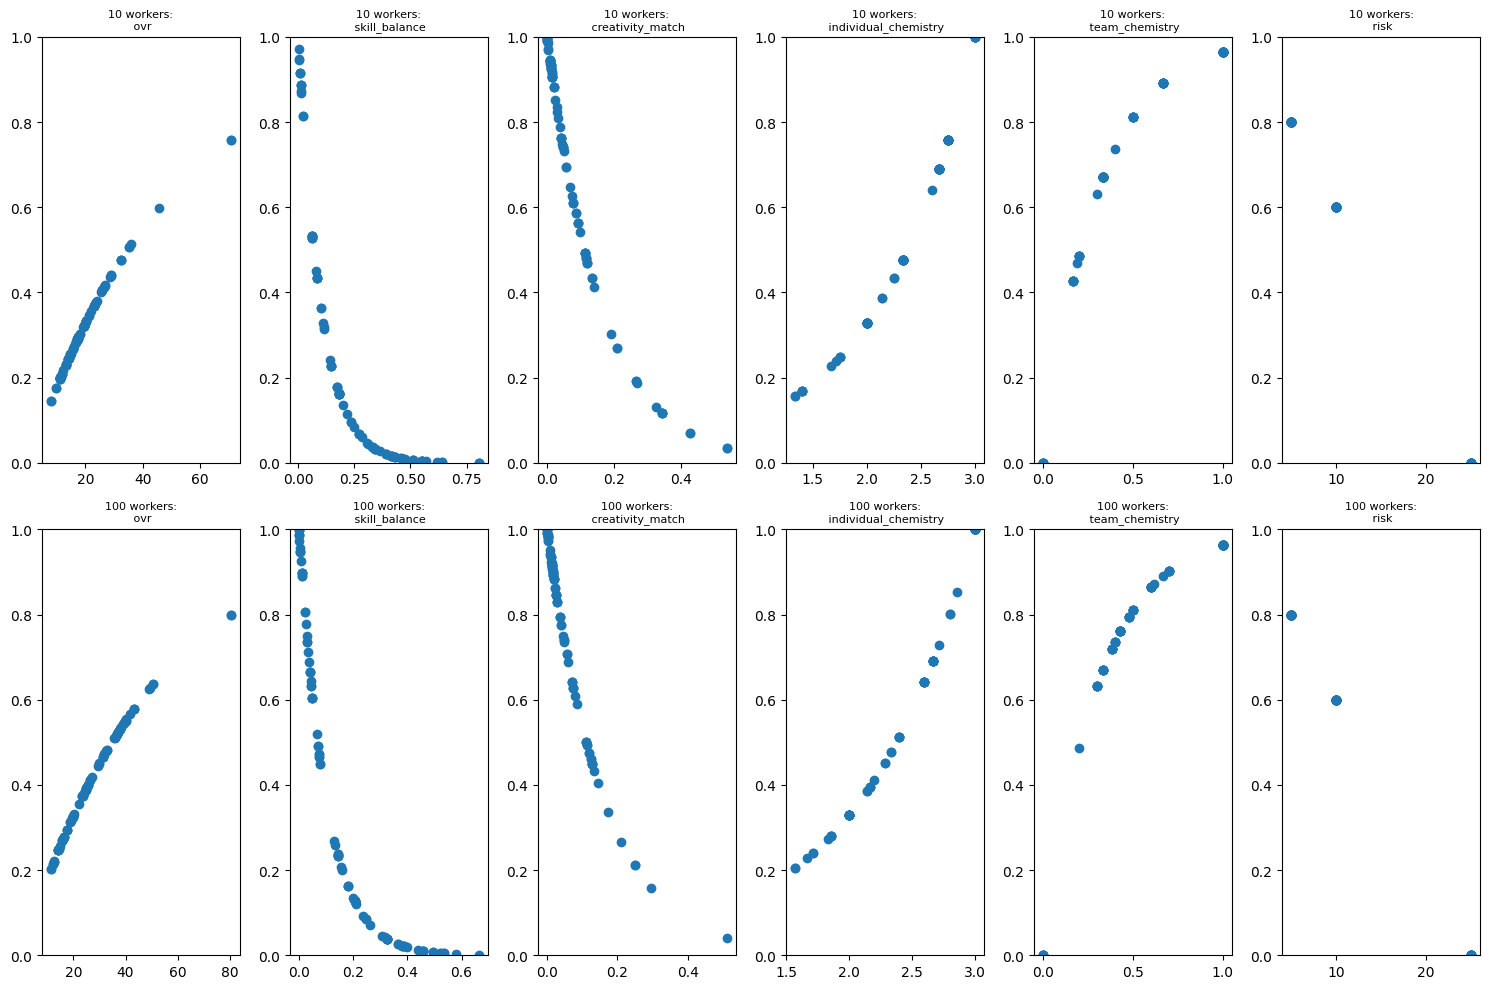

In [15]:
plot_id = 1
plt.figure(figsize=(15,10))
for cpt in components:
        
        print(cpt)
        plt.subplot(2,6,plot_id)
        X = results_10_workers[cpt]
        Y = results_10_workers['probability_' + cpt]
#         plt.axvline(np.mean(X), c='k', label='median: %.2f' % np.median(X))
        plt.scatter(X, Y)
        plt.ylim([0,1])
#         plt.legend()
        plt.title('10 workers:\n %s' % cpt, fontsize=8)
        
        plt.subplot(2,6,plot_id+6)
        Y = results_100_workers['probability_' + cpt]
        X = results_100_workers[cpt]
#         plt.axvline(np.mean(Y), c='k', label='mean: %.2f' % np.mean(Y))
#         plt.axvline(np.median(Y), c='r', label='median: %.2f' % np.median(Y))
        plt.ylim([0,1])
        plt.scatter(X, Y)
#         plt.legend()
        plt.title('100 workers:\n %s' % cpt, fontsize=8)
#         plt.scatter(X, Y)
        
#         x_min = min(X)
#         x_max = max(X)
#         y_min = min(Y)
#         y_max = max(Y)
        
#         mmin = min(x_min, y_min)
#         mmax = max(x_max, y_max)
        
#         plt.plot([mmin, mmax], [mmin, mmax], c='k')
#         plt.xlabel('10 workers')
#         plt.ylabel('100 workers')
#         plt.title(key, fontsize=10);
        plot_id += 1

plt.tight_layout()